In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams

# ---------- paper style ----------
rcParams["font.family"] = "Lato"
rcParams["font.size"] = 16
rcParams["text.color"] = "#3F3F3F"
rcParams["axes.labelcolor"] = "#3F3F3F"
rcParams["xtick.color"] = "#3F3F3F"
rcParams["ytick.color"] = "#3F3F3F"

TEAL = ["#b5d1ae", "#80ae9a", "#568b87", "#326b77", "#1b485e", "#122740"]

RNG = np.random.default_rng(42)
np.random.seed(42)


In [2]:
# Cell 2 — helper stats functions (Wilson CI + bootstrap CI)

def wilson_ci(k: int, n: int, alpha: float = 0.05):
    """
    Wilson score interval for a binomial proportion.
    Returns (phat, lo, hi). If n==0 returns (nan, nan, nan).
    """
    if n <= 0:
        return (np.nan, np.nan, np.nan)
    # 95% z for alpha=0.05; if you want exact z for other alphas, swap in scipy.stats.norm.ppf
    z = 1.959963984540054  
    phat = k / n
    denom = 1 + (z**2)/n
    center = (phat + (z**2)/(2*n)) / denom
    half = (z * np.sqrt((phat*(1-phat) + (z**2)/(4*n)) / n)) / denom
    return phat, max(0.0, center - half), min(1.0, center + half)

def bootstrap_ci(values: np.ndarray, stat_fn=np.mean, n_boot=10000, alpha=0.05, rng=None):
    """
    Nonparametric bootstrap CI for a statistic (default mean).
    Returns (stat, lo, hi).
    """
    values = np.asarray(values, dtype=float)
    values = values[~np.isnan(values)]
    if values.size == 0:
        return (np.nan, np.nan, np.nan)
    if rng is None:
        rng = np.random.default_rng(0)

    n = values.size
    boots = np.empty(n_boot, dtype=float)
    for i in range(n_boot):
        samp = rng.choice(values, size=n, replace=True)
        boots[i] = stat_fn(samp)

    stat = stat_fn(values)
    lo = np.quantile(boots, alpha/2)
    hi = np.quantile(boots, 1-alpha/2)
    return stat, lo, hi

def pretty_pct(p):
    if pd.isna(p): return "NA"
    return f"{100*p:.1f}%"

def pretty_ci(lo, hi):
    if pd.isna(lo) or pd.isna(hi): return "NA"
    return f"{100*lo:.1f}%–{100*hi:.1f}%"

In [4]:
CSV_PATH = "rmoi_and_ap_by_run_total.csv"

df = pd.read_csv(CSV_PATH)

expected_cols = {
    "type","target","peptide","run","RMOI","aggregation_propensity","matches_morphology_visual","notes_visual"
}
missing = expected_cols - set(df.columns)
if missing:
    raise ValueError(f"CSV missing columns: {missing}")

def _to_bool(x):
    if isinstance(x, bool):
        return x
    if pd.isna(x):
        return np.nan
    s = str(x).strip().lower()
    if s in {"yes","y","true","1"}: return True
    if s in {"no","n","false","0"}: return False
    return np.nan

df["vis_ok"] = df["matches_morphology_visual"].apply(_to_bool)
df["RMOI"] = pd.to_numeric(df["RMOI"], errors="coerce")
df["AP"] = pd.to_numeric(df["aggregation_propensity"], errors="coerce")

# basic cleanup
df["type"] = df["type"].astype(str).str.strip()
df["target"] = df["target"].astype(str).str.strip().str.lower()
df["peptide"] = df["peptide"].astype(str).str.strip()
df["run"] = df["run"].astype(str).str.strip()

# enforce canonical ordering (edit labels if your CSV differs)
TYPE_ORDER = ["original", "bigger_box_1230", "martini2"]
TARGET_ORDER = ["sphere", "fiber"]

df["type"] = pd.Categorical(df["type"], categories=TYPE_ORDER, ordered=True)
df["target"] = pd.Categorical(df["target"], categories=TARGET_ORDER, ordered=True)

df.head()


,type,target,peptide,run,RMOI,aggregation_propensity,matches_morphology_visual,notes_visual,vis_ok,AP
0,bigger_box_1230,fiber,CVSAPGIFHC,run_1,0.627750,2.218755,no,wide spherical aggregate,False,2.218755
1,bigger_box_1230,fiber,CVSAPGIFHC,run_2,0.372436,2.124790,yes,fiber,True,2.124790
2,bigger_box_1230,fiber,CVSAPGIFHC,run_3,0.305611,2.258243,yes,fiber,True,2.258243
3,martini2,fiber,CVSAPGIFHC,run_1,0.585417,2.196160,yes,intertwined fibers,True,2.196160
4,martini2,fiber,CVSAPGIFHC,run_2,0.358312,2.330696,yes,fiber,True,2.330696


In [5]:
print("Counts by type/target:")
display(df.groupby(["type","target"]).size().unstack(fill_value=0))

print("\nRuns per peptide (should typically be 3):")
runs_per_pep = df.groupby(["type","target","peptide"])["run"].nunique()
display(runs_per_pep.value_counts().sort_index())

bad_vis = df["vis_ok"].isna().sum()
bad_r = df["RMOI"].isna().sum()
bad_ap = df["AP"].isna().sum()
print(f"\nMissing/invalid vis_ok: {bad_vis}, RMOI: {bad_r}, AP: {bad_ap}")

Counts by type/target:


/tmp/ipykernel_2167247/2529295952.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  display(df.groupby(["type","target"]).size().unstack(fill_value=0))


target,sphere,fiber
type,,
original,24,24
bigger_box_1230,24,24
martini2,24,24



Runs per peptide (should typically be 3):


/tmp/ipykernel_2167247/2529295952.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  runs_per_pep = df.groupby(["type","target","peptide"])["run"].nunique()


run
0    48
3    48
Name: count, dtype: int64


Missing/invalid vis_ok: 0, RMOI: 0, AP: 0


In [10]:
run_rows = []
for (t, g), sub in df.groupby(["type", "target"], observed=True):
    n = int(sub["vis_ok"].notna().sum())
    k = int(sub["vis_ok"].fillna(False).sum())
    phat, lo, hi = wilson_ci(k, n)
    run_rows.append({
        "type": t, "target": g,
        "n_runs": n,
        "k_success": k,
        "run_success_rate": phat,
        "run_CI_lo": lo, "run_CI_hi": hi,
        "RMOI_mean": sub["RMOI"].mean(),
        "RMOI_std": sub["RMOI"].std(ddof=1),
        "AP_mean": sub["AP"].mean(),
        "AP_std": sub["AP"].std(ddof=1),
    })

run_summary = pd.DataFrame(run_rows).sort_values(["target","type"])
run_summary


,type,target,n_runs,k_success,run_success_rate,run_CI_lo,run_CI_hi,RMOI_mean,RMOI_std,AP_mean,AP_std
3,bigger_box_1230,fiber,24,10,0.416667,0.244676,0.611653,0.464529,0.132541,2.544777,0.342757
5,martini2,fiber,24,10,0.416667,0.244676,0.611653,0.521530,0.095499,2.194835,0.099450
1,original,fiber,24,18,0.750000,0.551006,0.880006,0.489610,0.185781,2.340821,0.272997
2,bigger_box_1230,sphere,24,19,0.791667,0.595295,0.907552,0.705393,0.194302,2.703879,0.545382
4,martini2,sphere,24,14,0.583333,0.388347,0.755324,0.638681,0.191968,2.455382,0.228545
0,original,sphere,24,20,0.833333,0.641469,0.933213,0.751538,0.170426,2.435553,0.381432


In [11]:
# Cell 6 — peptide-level (majority vote across runs) summaries + Wilson CIs

# per-peptide aggregates
pep = (df.groupby(["type","target","peptide"], observed=True)
         .agg(
             n_runs=("vis_ok","count"),
             k_runs_ok=("vis_ok","sum"),
             RMOI_mean=("RMOI","mean"),
             AP_mean=("AP","mean"),
         ))

pep["majority_ok"] = pep["k_runs_ok"] >= 2  # majority vote (>=2 out of 3)

pep_rows = []
for (t, g), sub in pep.groupby(["type","target"]):
    n = int(sub.shape[0])
    k = int(sub["majority_ok"].sum())
    phat, lo, hi = wilson_ci(k, n)
    pep_rows.append({
        "type": t, "target": g,
        "n_peptides": n,
        "k_success_peptides": k,
        "peptide_success_rate": phat,
        "pep_CI_lo": lo, "pep_CI_hi": hi,
        "RMOI_mean_over_peptides": sub["RMOI_mean"].mean(),
        "AP_mean_over_peptides": sub["AP_mean"].mean(),
    })

pep_summary = pd.DataFrame(pep_rows).sort_values(["target","type"])
pep_summary

/tmp/ipykernel_2167247/2723620903.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for (t, g), sub in pep.groupby(["type","target"]):


,type,target,n_peptides,k_success_peptides,peptide_success_rate,pep_CI_lo,pep_CI_hi,RMOI_mean_over_peptides,AP_mean_over_peptides
3,bigger_box_1230,fiber,8,4,0.500,0.215216,0.784784,0.464529,2.544777
5,martini2,fiber,8,3,0.375,0.136844,0.694258,0.521530,2.194835
1,original,fiber,8,6,0.750,0.409275,0.928521,0.489610,2.340821
2,bigger_box_1230,sphere,8,7,0.875,0.529112,0.977583,0.705393,2.703879
4,martini2,sphere,8,4,0.500,0.215216,0.784784,0.638681,2.455382
0,original,sphere,8,6,0.750,0.409275,0.928521,0.751538,2.435553


In [12]:
# Cell 7 — paired comparisons vs original (ΔRMOI, ΔAP, and flip counts)

# pivot per target so each peptide has columns per type
pivot = (pep.pivot_table(index=["target","peptide"],
                         columns="type",
                         values=["RMOI_mean","AP_mean","majority_ok"],
                         aggfunc="first")
           .sort_index())

# convenience getter (returns series aligned)
def get_col(metric, typ):
    return pivot[(metric, typ)]

paired_rows = []
for target in TARGET_ORDER:
    idx = pivot.index.get_level_values("target") == target
    psub = pivot[idx].copy()

    # require original present
    has_orig = psub[("majority_ok","original")].notna()
    psub = psub[has_orig]

    # compute deltas for each alt type
    for alt in [t for t in TYPE_ORDER if t != "original"]:
        if ("majority_ok", alt) not in psub.columns:
            continue

        # align peptides with both setups present
        both = psub[("majority_ok", alt)].notna() & psub[("majority_ok","original")].notna()
        p2 = psub[both].copy()

        d_r = (p2[("RMOI_mean", alt)] - p2[("RMOI_mean","original")]).to_numpy()
        d_ap = (p2[("AP_mean", alt)]   - p2[("AP_mean","original")]).to_numpy()

        # flip count (majority)
        flip = (p2[("majority_ok", alt)] != p2[("majority_ok","original")]).sum()
        n_pairs = p2.shape[0]

        # bootstrap CIs on mean deltas (small n => CI helpful)
        dr_mean, dr_lo, dr_hi = bootstrap_ci(d_r, stat_fn=np.mean, rng=RNG)
        dap_mean, dap_lo, dap_hi = bootstrap_ci(d_ap, stat_fn=np.mean, rng=RNG)

        paired_rows.append({
            "target": target,
            "comparison": f"{alt} - original",
            "n_paired_peptides": n_pairs,
            "flip_count_majority": int(flip),
            "mean_delta_RMOI": dr_mean, "delta_RMOI_CI_lo": dr_lo, "delta_RMOI_CI_hi": dr_hi,
            "mean_delta_AP": dap_mean, "delta_AP_CI_lo": dap_lo, "delta_AP_CI_hi": dap_hi,
        })

paired_summary = pd.DataFrame(paired_rows).sort_values(["target","comparison"])
paired_summary

/tmp/ipykernel_2167247/2079980777.py:4: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = (pep.pivot_table(index=["target","peptide"],


,target,comparison,n_paired_peptides,flip_count_majority,mean_delta_RMOI,delta_RMOI_CI_lo,delta_RMOI_CI_hi,mean_delta_AP,delta_AP_CI_lo,delta_AP_CI_hi
2,fiber,bigger_box_1230 - original,8,4,-0.025081,-0.098542,0.051650,0.203957,0.143878,0.263085
3,fiber,martini2 - original,8,5,0.031921,-0.043080,0.117113,-0.145986,-0.341604,0.043978
0,sphere,bigger_box_1230 - original,8,1,-0.046144,-0.118285,0.008570,0.268325,0.159062,0.387558
1,sphere,martini2 - original,8,4,-0.112857,-0.279230,0.047039,0.019829,-0.147508,0.184905


In [15]:
# Cell 8 — flip table (which peptides change classification vs original)

flip_tables = {}
for target in TARGET_ORDER:
    sub = pivot.loc[target].copy()  # index = peptide
    if ("majority_ok","original") not in sub.columns:
        continue
    out = pd.DataFrame(index=sub.index)
    out["orig_ok"] = sub[("majority_ok","original")]

    for alt in [t for t in TYPE_ORDER if t != "original"]:
        if ("majority_ok", alt) not in sub.columns:
            continue
        out[f"{alt}_ok"] = sub[("majority_ok", alt)]
        out[f"flip_{alt}"] = (out[f"{alt}_ok"] != out["orig_ok"]) & out[f"{alt}_ok"].notna() & out["orig_ok"].notna()

        # also include deltas
        out[f"delta_RMOI_{alt}"] = sub[("RMOI_mean", alt)] - sub[("RMOI_mean","original")]
        out[f"delta_AP_{alt}"]   = sub[("AP_mean", alt)]   - sub[("AP_mean","original")]

    # keep only rows that flip in any alt
    flip_cols = [c for c in out.columns if c.startswith("flip_")]
    if flip_cols:
        out = out[out[flip_cols].any(axis=1)].sort_index()
    flip_tables[target] = out

flip_tables.keys()

dict_keys(['sphere', 'fiber'])

In [16]:
flip_tables["sphere"]

,orig_ok,bigger_box_1230_ok,flip_bigger_box_1230,delta_RMOI_bigger_box_1230,delta_AP_bigger_box_1230,martini2_ok,flip_martini2,delta_RMOI_martini2,delta_AP_martini2
peptide,,,,,,,,,
FFIFI,True,True,False,-0.054631,0.434249,False,True,-0.413709,-0.156286
FIFIF,False,True,True,0.057828,0.246189,False,False,0.169480,0.350038
FIVVIF,True,True,False,0.014324,0.442263,False,True,-0.372880,-0.168014
FVIFF,True,True,False,0.015710,0.525512,False,True,-0.411354,-0.409576
VIFIL,False,False,False,-0.060225,0.068162,True,True,0.168427,0.297978


In [17]:
flip_tables["fiber"]

,orig_ok,bigger_box_1230_ok,flip_bigger_box_1230,delta_RMOI_bigger_box_1230,delta_AP_bigger_box_1230,martini2_ok,flip_martini2,delta_RMOI_martini2,delta_AP_martini2
peptide,,,,,,,,,
HYVSGRFLIY,True,False,True,0.031505,0.087858,False,True,0.076460,-0.067971
ILSFPDKVTY,True,True,False,0.012062,0.182805,False,True,0.097570,0.011088
LDIYNHPFF,True,False,True,0.171674,0.266060,False,True,0.258612,-0.561031
PFAIPYCSTP,False,True,True,-0.130218,0.264431,True,True,-0.116625,-0.310203
QIRTYDFLVF,True,False,True,-0.086767,0.079281,False,True,-0.065333,-0.088604


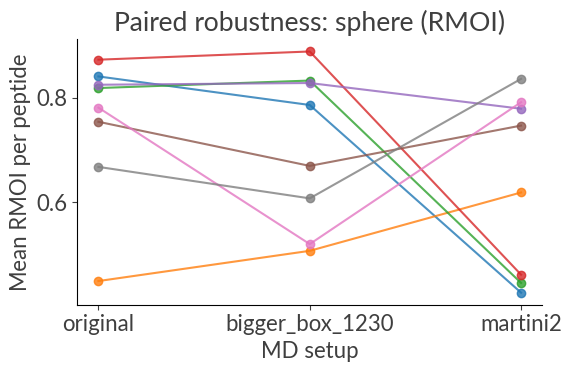

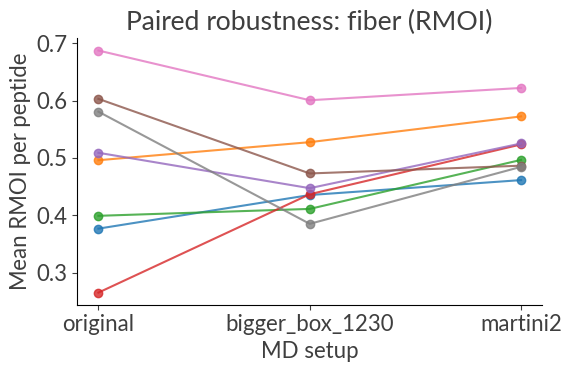

In [18]:
# Cell 9 — plot 1: paired per-peptide mean RMOI across setups (one plot per target)

def plot_paired_metric(metric="RMOI_mean", target="sphere", outpath=None):
    sub = pivot.loc[target].copy()  # index peptide
    # only peptides that exist in original (so lines anchor)
    if (metric, "original") not in sub.columns:
        raise ValueError("No original column found for this metric.")
    sub = sub[sub[(metric, "original")].notna()]

    # x positions
    x_types = [t for t in TYPE_ORDER if (metric, t) in sub.columns]
    x = np.arange(len(x_types))

    fig, ax = plt.subplots(figsize=(6.0, 4.0))

    # draw one line per peptide
    for pep_name, row in sub.iterrows():
        y = [row[(metric, t)] if (metric, t) in row.index else np.nan for t in x_types]
        ax.plot(x, y, marker="o", linewidth=1.5, alpha=0.8)

    # tidy
    for spine in ("top","right"):
        ax.spines[spine].set_visible(False)

    ax.set_xticks(x)
    ax.set_xticklabels(x_types, rotation=0)
    ax.set_xlabel("MD setup")
    ax.set_ylabel("Mean RMOI per peptide")
    ax.set_title(f"Paired robustness: {target} (RMOI)")

    plt.tight_layout()
    if outpath:
        fig.savefig(outpath, bbox_inches="tight", dpi=300)
    plt.show()

plot_paired_metric(metric="RMOI_mean", target="sphere", outpath="paired_rmois_sphere.pdf")
plot_paired_metric(metric="RMOI_mean", target="fiber",  outpath="paired_rmois_fiber.pdf")

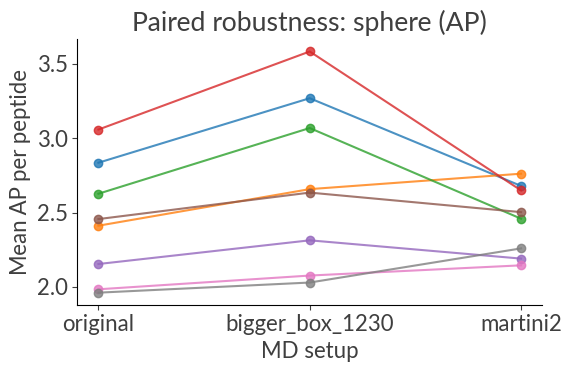

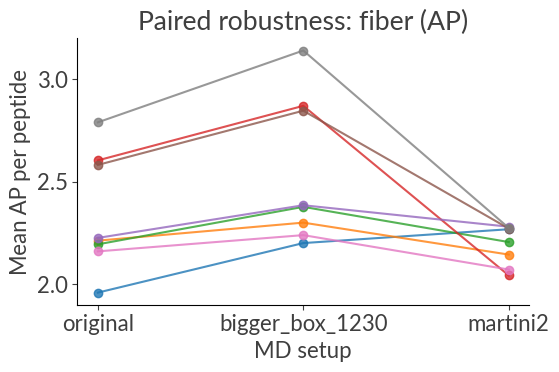

In [19]:
# Cell 10 — plot 2: paired per-peptide mean AP across setups (one plot per target)

def plot_paired_ap(target="sphere", outpath=None):
    sub = pivot.loc[target].copy()
    if ("AP_mean","original") not in sub.columns:
        raise ValueError("No original AP column found.")
    sub = sub[sub[("AP_mean","original")].notna()]

    x_types = [t for t in TYPE_ORDER if ("AP_mean", t) in sub.columns]
    x = np.arange(len(x_types))

    fig, ax = plt.subplots(figsize=(6.0, 4.0))

    for pep_name, row in sub.iterrows():
        y = [row[("AP_mean", t)] if ("AP_mean", t) in row.index else np.nan for t in x_types]
        ax.plot(x, y, marker="o", linewidth=1.5, alpha=0.8)

    for spine in ("top","right"):
        ax.spines[spine].set_visible(False)

    ax.set_xticks(x)
    ax.set_xticklabels(x_types, rotation=0)
    ax.set_xlabel("MD setup")
    ax.set_ylabel("Mean AP per peptide")
    ax.set_title(f"Paired robustness: {target} (AP)")

    plt.tight_layout()
    if outpath:
        fig.savefig(outpath, bbox_inches="tight", dpi=300)
    plt.show()

plot_paired_ap(target="sphere", outpath="paired_ap_sphere.pdf")
plot_paired_ap(target="fiber",  outpath="paired_ap_fiber.pdf")

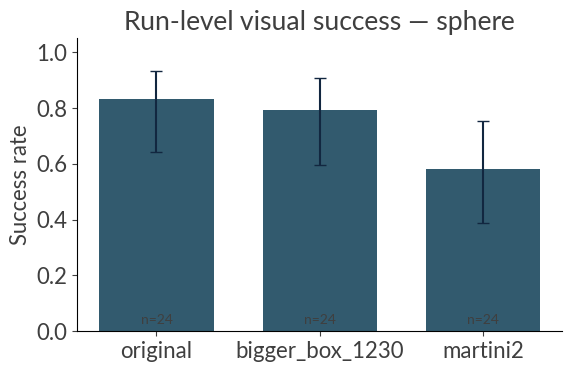

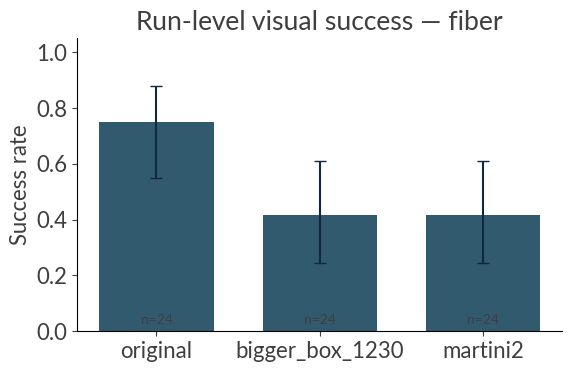

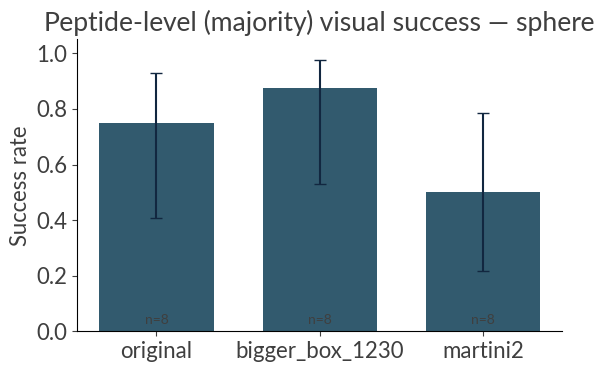

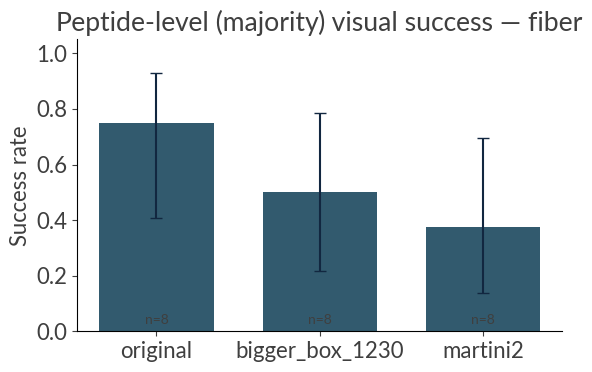

In [20]:
# Cell 11 — plot 3: success rates with Wilson CIs (run-level and peptide-level)

def plot_success_bars(summary_df, rate_col, lo_col, hi_col, n_col, title, outpath=None):
    # expects columns: type, target, rate_col, lo_col, hi_col
    for target in TARGET_ORDER:
        sub = summary_df[summary_df["target"].astype(str) == target].copy()
        sub = sub.sort_values("type")

        x_types = [t for t in TYPE_ORDER if t in set(sub["type"].astype(str))]
        sub = sub.set_index("type").reindex(x_types).reset_index()

        x = np.arange(len(x_types))
        y = sub[rate_col].to_numpy(dtype=float)
        ylo = sub[lo_col].to_numpy(dtype=float)
        yhi = sub[hi_col].to_numpy(dtype=float)

        # errorbars
        err_lo = y - ylo
        err_hi = yhi - y

        fig, ax = plt.subplots(figsize=(6.0, 4.0))
        ax.bar(x, y, width=0.7, color=TEAL[4], alpha=0.9, linewidth=0)
        ax.errorbar(x, y, yerr=[err_lo, err_hi], fmt="none", ecolor=TEAL[5], capsize=4, linewidth=1.5)

        for spine in ("top","right"):
            ax.spines[spine].set_visible(False)

        ax.set_xticks(x)
        ax.set_xticklabels(x_types)
        ax.set_ylim(0, 1.05)
        ax.set_ylabel("Success rate")
        ax.set_title(f"{title} — {target}")

        # annotate n
        for i, n in enumerate(sub[n_col].to_numpy()):
            if pd.notna(n):
                ax.text(i, 0.02, f"n={int(n)}", ha="center", va="bottom", fontsize=10, color="#3F3F3F")

        plt.tight_layout()
        if outpath:
            fig.savefig(outpath.replace(".pdf", f"_{target}.pdf"), bbox_inches="tight", dpi=300)
        plt.show()

plot_success_bars(
    run_summary.assign(type=run_summary["type"].astype(str), target=run_summary["target"].astype(str)),
    rate_col="run_success_rate", lo_col="run_CI_lo", hi_col="run_CI_hi", n_col="n_runs",
    title="Run-level visual success", outpath="success_runlevel.pdf"
)

plot_success_bars(
    pep_summary.assign(type=pep_summary["type"].astype(str), target=pep_summary["target"].astype(str)),
    rate_col="peptide_success_rate", lo_col="pep_CI_lo", hi_col="pep_CI_hi", n_col="n_peptides",
    title="Peptide-level (majority) visual success", outpath="success_peptidelevel.pdf"
)

In [21]:
# Cell 12 — assemble a single SI summary table (recommended "Table Sx")

def build_si_summary_table(run_summary, pep_summary):
    r = run_summary.copy()
    p = pep_summary.copy()

    # harmonize keys as strings for merge
    r["type"] = r["type"].astype(str); r["target"] = r["target"].astype(str)
    p["type"] = p["type"].astype(str); p["target"] = p["target"].astype(str)

    out = pd.merge(r, p, on=["type","target"], how="outer", suffixes=("_run","_pep"))

    def fmt_rate(k, n):
        phat, lo, hi = wilson_ci(int(k), int(n)) if (pd.notna(k) and pd.notna(n) and n > 0) else (np.nan,np.nan,np.nan)
        return f"{int(k)}/{int(n)} = {pretty_pct(phat)} ({pretty_ci(lo,hi)})"

    out["run_success"] = out.apply(lambda s: fmt_rate(s["k_success"], s["n_runs"]) if pd.notna(s["n_runs"]) else "NA", axis=1)
    out["pep_success"] = out.apply(lambda s: fmt_rate(s["k_success_peptides"], s["n_peptides"]) if pd.notna(s["n_peptides"]) else "NA", axis=1)

    # compact stats
    out["RMOI_mean±sd (runs)"] = out.apply(
        lambda s: f"{s['RMOI_mean']:.3f} ± {s['RMOI_std']:.3f}" if pd.notna(s["RMOI_mean"]) else "NA", axis=1
    )
    out["AP_mean±sd (runs)"] = out.apply(
        lambda s: f"{s['AP_mean']:.3f} ± {s['AP_std']:.3f}" if pd.notna(s["AP_mean"]) else "NA", axis=1
    )

    cols = ["type","target","run_success","pep_success","RMOI_mean±sd (runs)","AP_mean±sd (runs)"]
    return out[cols].sort_values(["target","type"])

si_table = build_si_summary_table(run_summary, pep_summary)
si_table

,type,target,run_success,pep_success,RMOI_mean±sd (runs),AP_mean±sd (runs)
0,bigger_box_1230,fiber,10/24 = 41.7% (24.5%–61.2%),4/8 = 50.0% (21.5%–78.5%),0.465 ± 0.133,2.545 ± 0.343
2,martini2,fiber,10/24 = 41.7% (24.5%–61.2%),3/8 = 37.5% (13.7%–69.4%),0.522 ± 0.095,2.195 ± 0.099
4,original,fiber,18/24 = 75.0% (55.1%–88.0%),6/8 = 75.0% (40.9%–92.9%),0.490 ± 0.186,2.341 ± 0.273
1,bigger_box_1230,sphere,19/24 = 79.2% (59.5%–90.8%),7/8 = 87.5% (52.9%–97.8%),0.705 ± 0.194,2.704 ± 0.545
3,martini2,sphere,14/24 = 58.3% (38.8%–75.5%),4/8 = 50.0% (21.5%–78.5%),0.639 ± 0.192,2.455 ± 0.229
5,original,sphere,20/24 = 83.3% (64.1%–93.3%),6/8 = 75.0% (40.9%–92.9%),0.752 ± 0.170,2.436 ± 0.381


/tmp/ipykernel_2167247/3479841811.py:30: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  run_sum = (d.groupby(["type", "target"], as_index=False)


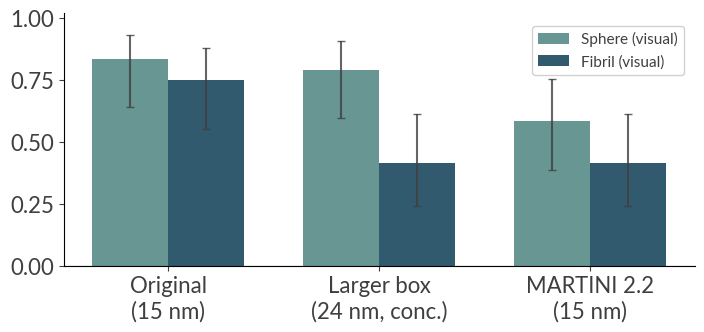

In [32]:
# ============================================================
# SI FIGURE 1 — Robustness success rates (run-level; Wilson CIs)
# Assumes you already loaded the controls CSV into a DataFrame `df`
# with columns: type, target, peptide, run, RMOI, aggregation_propensity, matches_morphology_visual
# and that rcParams + TEAL are already set as in your snippet.
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def wilson_ci(k, n, z=1.959963984540054):
    """Wilson 95% CI for a binomial proportion."""
    if n == 0:
        return (np.nan, np.nan, np.nan)
    phat = k / n
    denom = 1 + (z**2)/n
    center = (phat + (z**2)/(2*n)) / denom
    half = (z * np.sqrt((phat*(1-phat)/n) + (z**2)/(4*n**2))) / denom
    return phat, max(0.0, center-half), min(1.0, center+half)

# --- clean yes/no and standardize
d = df.copy()
d["matches_morphology_visual"] = (
    d["matches_morphology_visual"].astype(str).str.strip().str.lower()
)
d["ok"] = d["matches_morphology_visual"].isin(["yes", "true", "1", "y"])

# run-level summary
run_sum = (d.groupby(["type", "target"], as_index=False)
             .agg(n_runs=("ok","size"),
                  k_success=("ok","sum"),
                  RMOI_mean=("RMOI","mean"),
                  RMOI_std=("RMOI","std"),
                  AP_mean=("aggregation_propensity","mean"),
                  AP_std=("aggregation_propensity","std")))

ci = run_sum.apply(lambda r: wilson_ci(int(r["k_success"]), int(r["n_runs"])), axis=1, result_type="expand")
run_sum["p"] = ci[0]; run_sum["ci_lo"] = ci[1]; run_sum["ci_hi"] = ci[2]

# order to match your SI narrative
setup_order = ["original", "bigger_box_1230", "martini2"]
target_order = ["sphere", "fiber"]
run_sum["type"] = pd.Categorical(run_sum["type"], categories=setup_order, ordered=True)
run_sum["target"] = pd.Categorical(run_sum["target"], categories=target_order, ordered=True)
run_sum = run_sum.sort_values(["type","target"]).reset_index(drop=True)

# --- grouped bars with Wilson CI error bars (single-axis, paper style)
fig, ax = plt.subplots(figsize=(7.2, 3.6))

x = np.arange(len(setup_order))
w = 0.36

def _get(series_target):
    s = run_sum[run_sum["target"] == series_target].set_index("type").reindex(setup_order)
    return s["p"].to_numpy(), s["ci_lo"].to_numpy(), s["ci_hi"].to_numpy()

p_s, lo_s, hi_s = _get("sphere")
p_f, lo_f, hi_f = _get("fiber")

err_s = np.vstack([p_s - lo_s, hi_s - p_s])
err_f = np.vstack([p_f - lo_f, hi_f - p_f])

ax.bar(x - w/2, p_s, width=w, color=TEAL[2], alpha=0.9, linewidth=0, label="Sphere (visual)")
ax.bar(x + w/2, p_f, width=w, color=TEAL[4], alpha=0.9, linewidth=0, label="Fibril (visual)")

ax.errorbar(x - w/2, p_s, yerr=err_s, fmt="none", ecolor=rcParams["text.color"],
            elinewidth=1.5, capsize=3, alpha=0.8)
ax.errorbar(x + w/2, p_f, yerr=err_f, fmt="none", ecolor=rcParams["text.color"],
            elinewidth=1.5, capsize=3, alpha=0.8)

ax.axhline(0, linewidth=1, alpha=0.25, color=rcParams["text.color"])
ax.set_ylim(0, 1.02)
ax.set_xticks(x)
ax.set_xticklabels(["Original\n(15 nm)", "Larger box\n(24 nm, conc.)", "MARTINI 2.2\n(15 nm)"])

for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)

leg = ax.legend(loc="upper right", bbox_to_anchor=(0.995, 0.98),
                frameon=True, fancybox=True, framealpha=0.9, fontsize=11)

plt.tight_layout()
plt.show()

fig.savefig("robustness_success_rates.pdf", format="pdf", bbox_inches="tight")

/tmp/ipykernel_2167247/2243058872.py:49: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  wide = (pep.pivot_table(index=["target","peptide"],


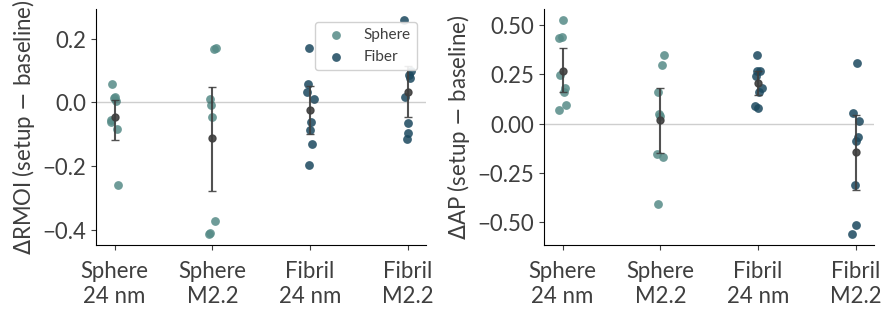

In [34]:
# ============================================================
# SI FIGURE 2 — Paired deltas vs baseline (per peptide)
# Produces a 1x2 figure: ΔRMOI and ΔAP (each point = peptide)
# with mean ± 95% bootstrap CI over peptides (not runs).
# ============================================================

# ------------------------------------------------------------
# SAFE peptide-level aggregation (no lambda, no broadcasting)
# ------------------------------------------------------------

# 0) Make sure we are working from a clean base
d0 = df.copy().reset_index(drop=True)

# 1) Normalize morphology match column → boolean
d0["matches_morphology_visual"] = (
    d0["matches_morphology_visual"]
      .astype(str).str.strip().str.lower()
)
d0["ok"] = d0["matches_morphology_visual"].isin(["yes", "true", "1", "y"])

# 2) Sanity check (fail early if notebook state is broken)
required_cols = {"type", "target", "peptide", "ok", "RMOI", "aggregation_propensity"}
missing = required_cols - set(d0.columns)
if missing:
    raise KeyError(f"Missing columns in df: {missing}")

# 3) Aggregate explicitly
pep = (
    d0
    .groupby(["type", "target", "peptide"], observed=True)
    .agg(
        n_runs=("ok", "size"),
        k_success=("ok", "sum"),
        RMOI_mean=("RMOI", "mean"),
        AP_mean=("aggregation_propensity", "mean"),
    )
    .reset_index()
)

# 4) Majority rule (2 out of 3 runs)
pep["ok_majority"] = pep["k_success"] >= 2

# enforce same ordering
pep["type"] = pd.Categorical(pep["type"], categories=setup_order, ordered=True)
pep["target"] = pd.Categorical(pep["target"], categories=target_order, ordered=True)
pep = pep.sort_values(["target","peptide","type"]).reset_index(drop=True)

# wide per target
wide = (pep.pivot_table(index=["target","peptide"],
                        columns="type",
                        values=["RMOI_mean","AP_mean","ok_majority"],
                        aggfunc="first"))

# helper for bootstrap CI (peptide-level)
def boot_ci(x, n_boot=20000, alpha=0.05, seed=0):
    x = np.asarray(x, dtype=float)
    x = x[~np.isnan(x)]
    if len(x) == 0:
        return (np.nan, np.nan)
    rng = np.random.default_rng(seed)
    boots = rng.choice(x, size=(n_boot, len(x)), replace=True).mean(axis=1)
    lo = np.quantile(boots, alpha/2)
    hi = np.quantile(boots, 1 - alpha/2)
    return lo, hi

# build long deltas table
rows = []
for tgt in target_order:
    for comp in ["bigger_box_1230", "martini2"]:
        base = "original"
        sub = wide.loc[tgt].dropna(subset=[("RMOI_mean", base), ("RMOI_mean", comp),
                                           ("AP_mean", base), ("AP_mean", comp)])
        dr = sub[("RMOI_mean", comp)] - sub[("RMOI_mean", base)]
        da = sub[("AP_mean", comp)]   - sub[("AP_mean", base)]
        flip = sub[("ok_majority", comp)] != sub[("ok_majority", base)]
        for pepname in sub.index:
            rows.append({
                "target": tgt,
                "comparison": f"{comp} - {base}",
                "peptide": pepname,
                "delta_RMOI": float(dr.loc[pepname]),
                "delta_AP": float(da.loc[pepname]),
                "flip": bool(flip.loc[pepname]),
            })

deltas = pd.DataFrame(rows)

# category order on x-axis
cat_order = [
    ("sphere", "bigger_box_1230 - original"),
    ("sphere", "martini2 - original"),
    ("fiber",  "bigger_box_1230 - original"),
    ("fiber",  "martini2 - original"),
]
deltas["cat"] = deltas.apply(lambda r: (r["target"], r["comparison"]), axis=1)
deltas["cat"] = pd.Categorical(deltas["cat"], categories=cat_order, ordered=True)
deltas = deltas.sort_values("cat").reset_index(drop=True)

# x positions + light deterministic jitter
x_base = np.arange(len(cat_order))
jitter = (np.arange(len(deltas)) % 7 - 3) * 0.012  # deterministic small spread
deltas["x"] = deltas["cat"].cat.codes + jitter

# plot
fig, axs = plt.subplots(1, 2, figsize=(9.2, 3.6), sharex=True)

# colors by target
color_map = {"sphere": TEAL[2], "fiber": TEAL[4]}

for ax, col, ylab in zip(
    axs,
    ["delta_RMOI", "delta_AP"],
    [r"$\Delta$RMOI (setup $-$ baseline)", r"$\Delta$AP (setup $-$ baseline)"]
):
    for tgt in target_order:
        sub = deltas[deltas["target"] == tgt]
        ax.scatter(sub["x"], sub[col],
                   s=40, color=color_map[tgt], alpha=0.85, linewidth=0,
                   label=tgt.capitalize() if col == "delta_RMOI" else None)

    # overlay peptide-mean + bootstrap CI per category
    for i, cat in enumerate(cat_order):
        vals = deltas.loc[deltas["cat"] == cat, col].to_numpy()
        m = np.nanmean(vals) if len(vals) else np.nan
        lo, hi = boot_ci(vals, seed=i+1)
        ax.errorbar(i, m, yerr=np.array([[m-lo],[hi-m]]), fmt="o",
                    color=rcParams["text.color"], markersize=5,
                    elinewidth=1.5, capsize=3, alpha=0.9)

    ax.axhline(0, linewidth=1, alpha=0.25, color=rcParams["text.color"])
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)
    ax.set_ylabel(ylab)

xticklabels = [
    "Sphere\n24 nm",
    "Sphere\nM2.2",
    "Fibril\n24 nm",
    "Fibril\nM2.2",
]

for ax in axs:
    ax.set_xticks(x_base)
    ax.set_xticklabels(xticklabels)
    ax.tick_params(axis="x", pad=8)
    for lab in ax.get_xticklabels():
        lab.set_ha("center")
        lab.set_multialignment("center")

axs[0].legend(loc="upper right", bbox_to_anchor=(0.995, 0.98),
              frameon=True, fancybox=True, framealpha=0.9, fontsize=11)

plt.tight_layout()
fig.subplots_adjust(bottom=0.28)
plt.show()

fig.savefig("robustness_paired_deltas.svg", format="svg", bbox_inches="tight", dpi=300)
fig.savefig("robustness_paired_deltas.pdf", format="pdf", bbox_inches="tight")